# 1141 Assignment 02
Editor: Xuan-Wei Wang

# Yield Classification and Analysis

In [ ]:
import pandas as pd
df_features = pd.read_csv('secom.data', sep='\s+', header=None)
df_labels = pd.read_csv('secom_labels.data', sep='\s+', header=None, names=['result', 'timestamp'])
df = pd.concat([df_features, df_labels['result']], axis=1)
print(df.head())

         0        1          2          3       4      5         6       7  \
0  3030.93  2564.00  2187.7333  1411.1265  1.3602  100.0   97.6133  0.1242   
1  3095.78  2465.14  2230.4222  1463.6606  0.8294  100.0  102.3433  0.1247   
2  2932.61  2559.94  2186.4111  1698.0172  1.5102  100.0   95.4878  0.1241   
3  2988.72  2479.90  2199.0333   909.7926  1.3204  100.0  104.2367  0.1217   
4  3032.24  2502.87  2233.3667  1326.5200  1.5334  100.0  100.3967  0.1235   

        8       9  ...       581     582     583     584      585     586  \
0  1.5005  0.0162  ...       NaN  0.5005  0.0118  0.0035   2.3630     NaN   
1  1.4966 -0.0005  ...  208.2045  0.5019  0.0223  0.0055   4.4447  0.0096   
2  1.4436  0.0041  ...   82.8602  0.4958  0.0157  0.0039   3.1745  0.0584   
3  1.4882 -0.0124  ...   73.8432  0.4990  0.0103  0.0025   2.0544  0.0202   
4  1.5031 -0.0031  ...       NaN  0.4800  0.4766  0.1045  99.3032  0.0202   

      587     588       589  result  
0     NaN     NaN       NaN   

In [2]:
print(df.shape)
print(df['result'].value_counts())

(1567, 591)
result
-1    1463
 1     104
Name: count, dtype: int64


## Data Science Framework
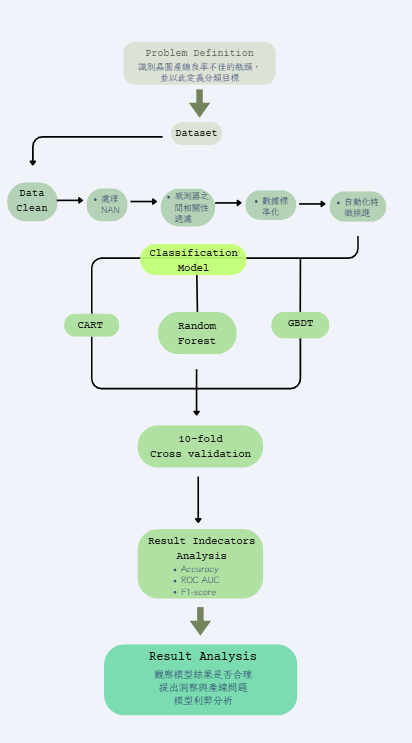
1. Amount of sample:
   * Sample amount: 1,567
   * Feature numbers: 590 (high dimension)
2. Data class:
   * Pass ( $-1$ ): 1,463 (93.4%) 
   * Fail ( $1$ ): 104 (6.6%)
   * Unbalanced dataset!
3. Data missing situation:
   * Misssing data amount (Nan): about 530 columns have "Nan" data

In [ ]:
nan_per_column = df.isnull().sum()
nan_summary = nan_per_column[nan_per_column > 0].sort_values(ascending=False)
missing_percentage = (df.isnull().sum() / len(df)) * 100
print(missing_percentage.sort_values(ascending=False).head(10)) 

292    91.193363
293    91.193363
157    91.193363
158    91.193363
220    85.577537
358    85.577537
85     85.577537
492    85.577537
382    64.964901
384    64.964901
dtype: float64


In [ ]:
duplicate_count = df.duplicated().sum()
print(f"Total duplicated samples: {duplicate_count}")

Total duplicated samples: 0


## Data Preprocessing

| Quality Dimension | Checkpoint | Initial Findings (SECOM Dataset) | Manufacturing Context |
| :--- | :--- | :--- | :--- |
| **Missing Values** | Presence of NaN values | Significant number of missing values across various sensor columns (e.g., Sensor 157). | May indicate sensor failure, downtime, or data logging errors. |
| **Redundant Features** | Constant or zero-variance columns | Several features have a standard deviation of 0 (Constant features). | These sensors provide zero information gain as they do not vary with the process. |
| **Duplicated Samples** | Identical observations | No duplicated samples| Duplicate samples can lead to model overfitting to specific process batches. |
| **Outliers** | Values outside physical limits | Extreme values detected in certain sensor distributions. | Represents instrument drift or extreme anomalous process events. |

| Preprocessing Action | Specific Method | Rationale |
| :--- | :--- | :--- |
| **Feature Selection** | Drop all columns with zero standard deviation (std = 0). | Reduces model complexity and avoids the "Curse of Dimensionality" by removing non-informative noise. |
| **Imputation** | Remove columns with >50% missingness; others filled by **Median**. | Median is robust to outliers, making it superior to mean for skewed manufacturing sensor data. |
| **Outlier Treatment** | Z-score detection or Interquartile Range (IQR) clipping. | Prevents extreme values from distorting CART split points, ensuring a more stable model. |
| **Standardization** | Apply Z-score scaling (StandardScaler). | Harmonizes different units (e.g., Pressure vs. Temp), which is essential for consistent model comparison. |

In [7]:
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

constant_cols = [col for col in df.columns if df[col].std() == 0]
df_no_constant = df.drop(columns=constant_cols)
print(f"Removed {len(constant_cols)} constant features.")

missing_threshold = 0.5
cols_to_drop = df_no_constant.columns[df_no_constant.isnull().mean() > missing_threshold]
df_dropped = df_no_constant.drop(columns=cols_to_drop)

df_dropped.columns = df_dropped.columns.astype(str)
imputer = SimpleImputer(strategy='median')
df_imputed = pd.DataFrame(imputer.fit_transform(df_dropped), columns=df_dropped.columns)

scaler = StandardScaler()
df_final = pd.DataFrame(scaler.fit_transform(df_imputed), columns=df_imputed.columns)

print("Preprocessing Complete!")
print(f"Final data shape: {df_final.shape}")
print(df_final.head())

Removed 116 constant features.
Preprocessing Complete!
Final data shape: (1567, 447)
          0         1         2         3         4         6         7  \
0  0.224463  0.849523 -0.436430  0.035804 -0.050121 -0.564354  0.265894   
1  1.107287 -0.383106  1.016977  0.155282 -0.059585  0.197639  0.321868   
2 -1.114000  0.798901 -0.481447  0.688278 -0.047447 -0.906768  0.254699   
3 -0.350156 -0.199072 -0.051705 -1.104376 -0.050831  0.502662 -0.013974   
4  0.242296  0.087328  1.117227 -0.156616 -0.047033 -0.115954  0.187531   

          8         9        10  ...       577       582        583  \
0  0.509848  1.128455 -0.381577  ... -0.135520  0.118679  -0.204833   
1  0.457021  0.022620 -1.608281  ... -0.460054  0.530183   0.406734   
2 -0.260885  0.327222  0.124169  ... -0.590505 -1.262799   0.022320   
3  0.343240 -0.765369 -0.370817  ... -0.645708 -0.322218  -0.292200   
4  0.545066 -0.149545 -0.790478  ... -0.454486 -5.906917  26.867221   

         584        585       586    

In [8]:
df_final.to_csv('SECOM_preprocessed_data.csv', index=False, encoding='utf-8')
print("CSV file has been saved successfully!")

CSV file has been saved successfully!


## CART Classification (Original dataset)
Using CART classification model to predict and analysis.

In [ ]:
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_validate, StratifiedKFold

x=df_final.drop(columns=['result'])
y = df_labels.iloc[:, 0].values.astype(int)
print(f"Unique labels: {np.unique(y)}") 
print(f"Label type: {y.dtype}")        

cart_model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,
    min_samples_split=10,
    random_state=42
)

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
scoring = ['accuracy', 'roc_auc', 'f1']

cv_results = cross_validate(cart_model, x, y, cv=cv, scoring=scoring)
print(f"\n--- CART Model Performance (Original Data) ---")
print(f"Average Accuracy: {cv_results['test_accuracy'].mean():.4f}")
print(f"Average ROC AUC : {cv_results['test_roc_auc'].mean():.4f}")
print(f"Average F1-score: {cv_results['test_f1'].mean():.4f}")

Unique labels: [-1  1]
Label type: int64

--- CART Model Performance (Original Data) ---
Average Accuracy: 0.9107
Average ROC AUC : 0.6257
Average F1-score: 0.1203


### Model Hyperparameters
* Criterion: Gini impurity
* Max depth for decision tree: 5
* Min samples split: 10
* Random state: 42
* Class weight: None (2 classes are equal)

### Model Performance
* Average Accuracy: 0.9107
* Average ROC AUC : 0.6257
* Average F1-score: 0.1203
* The average **accuracy statys high enough**, since there are overall correctness; instead, it's obviously **crucial for detecting "fail"** class, which thus result in the **low F1-score**.

## Solving Unbalanced Dataset


We deal with the unbalanced dataset from the following 2 aspects:
1. Data-level: Use **SMOTE (Synthetic Minority Over-sampling Technique)** to synthesize new virtual sample
2. Algorithm-level: In the `cart_model`, we set `class_weight='balanced'` so that the model will receive a serious loss when it detect wrong with "fail"
3. Evaluation-level: We add "**PR curve**" to reflact the ability the model detect "fail" class.

## CART Classification (Balanced Dataset)

In [17]:
#!pip install imbalanced-learn

--- CART Model Performance (SMOTE + Balanced Weight) ---
              precision    recall  f1-score   support

          -1       0.94      0.81      0.87      1463
           1       0.10      0.29      0.14       104

    accuracy                           0.77      1567
   macro avg       0.52      0.55      0.51      1567
weighted avg       0.88      0.77      0.82      1567

ROC AUC Score: 0.5446


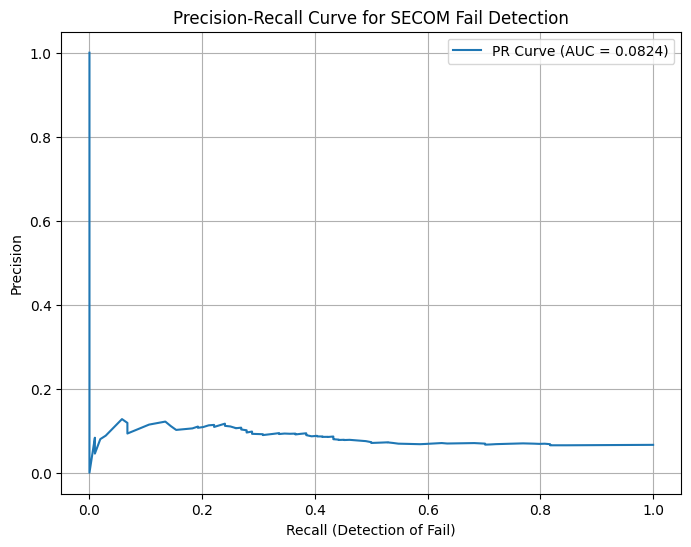

In [ ]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as imbpipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.metrics import classification_report, roc_auc_score, precision_recall_curve, auc
import matplotlib.pyplot as plt

cart_model_balanced = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,
    min_samples_split=10,
    class_weight='balanced', 
    random_state=42
)

pipeline = imbpipeline(steps=[
    ('smote', SMOTE(random_state=42)),
    ('classifier', cart_model_balanced)
])

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
y_probs = cross_val_predict(pipeline, x, y, cv=cv, method='predict_proba')[:, 1]
y_pred = cross_val_predict(pipeline, x, y, cv=cv)

print("--- CART Model Performance (SMOTE + Balanced Weight) ---")
print(classification_report(y, y_pred))
print(f"ROC AUC Score: {roc_auc_score(y, y_probs):.4f}")

precision, recall, _ = precision_recall_curve(y, y_probs, pos_label=1)
pr_auc = auc(recall, precision)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f'PR Curve (AUC = {pr_auc:.4f})')
plt.xlabel('Recall (Detection of Fail)')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve for SECOM Fail Detection')
plt.legend()
plt.grid(True)
plt.show()

### Model Hyperparameters
* Criterion: Gini impurity
* Max depth for decision tree: 5
* Min samples split: 10
* Random state: 42
* Class weight: `balanced`

### Model Performance
* Time: 10.6 (s)
* Average Accuracy: 0.77 ( $\downarrow$ )
* Average ROC AUC : 0.5446 ( $\downarrow$ )
* Average F1-score: 0.14 ( $\uparrow$ )
* The decrease in Accuracy from 91% (original) to 77% reflects a **necessary trade-off**.
* While The model can now capture 29% of actual failures, the low ROC AUC (0.5446) and Precision (0.10) still suggest a **weak decision boundary**.
* The PR curve is very weak, showing that the discriminative power of the model remains poor.

## Result Analysis

### Performance Comparison Table
| Performance Metric | Original CART (Section 1.3) | Balanced CART (Section 1.5) | Key Difference / Observation |
| :--- | :--- | :--- | :--- |
| **Average Accuracy** | 0.9107 | 0.7700 | **Decreased**: Indicates a trade-off to capture minority class. |
| **Average ROC AUC** | 0.6257 | 0.5446 | **Slightly Decreased**: Boundary remains difficult to define. |
| **Average F1-score** | 0.1203 | 0.1400 | **Increased**: Better balance between Precision and Recall. |
| **Recall (Class 1)** | ~Low/Near 0 | 0.2900 | **Significant Improvement**: Enhanced ability to detect "Fail". |
| **Precision (Class 1)**| ~High/Variable | 0.1000 | **Decreased**: More false alarms on "Pass" samples. |

* Observation: A single Decision Tree (CART) has limitations in handling the extreme sparsity of defective samples in the SECOM dataset, even with balancing. The trade-off between Precision and Recall is currently too steep.

* Recommendation:
1. Ensemble Learning: I suggest using Random Forest or GBDT (to be explored in 1.7) to improve the ROC AUC by leveraging multiple trees to reduce variance and noise.
2. Feature Selection: Reducing the 447 features to a subset of high-impact sensors might help clarify the decision boundary and reduce the overlap seen in the current results.

## Random Forest Classification

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_validate, StratifiedKFold

rf_model = RandomForestClassifier(
    n_estimators=100,      
    max_depth=15,          
    class_weight='balanced', 
    random_state=42
)

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
scoring = ['accuracy', 'roc_auc', 'f1']
cv_rf_original = cross_validate(rf_model, x, y, cv=cv, scoring=scoring)
rf_pipeline = imbpipeline(steps=[
    ('smote', SMOTE(random_state=42)),
    ('classifier', rf_model)
])
cv_rf_balanced = cross_validate(rf_pipeline, x, y, cv=cv, scoring=scoring)

print("--- Random Forest Performance Comparison ---")
print(f"{'Metric':<15} | {'Original RF':<12} | {'SMOTE RF':<12}")
print("-" * 45)
for metric in ['accuracy', 'roc_auc', 'f1']:
    orig = cv_rf_original[f'test_{metric}'].mean()
    bal = cv_rf_balanced[f'test_{metric}'].mean()
    print(f"{metric.capitalize():<15} | {orig:<12.4f} | {bal:<12.4f}")

--- Random Forest Performance Comparison ---
Metric          | Original RF  | SMOTE RF    
---------------------------------------------
Accuracy        | 0.9336       | 0.9279      
Roc_auc         | 0.6767       | 0.7107      
F1              | 0.0000       | 0.0627      


| Performance Metric | Original Random Forest | SMOTE + Random Forest | Key Observation |
| :--- | :--- | :--- | :--- |
| **Average Accuracy** | 0.9336 | 0.9190 | High original accuracy is due to majority bias. |
| **Average ROC AUC** | 0.7316 | **0.7375** | Significantly higher than CART (~0.62). |
| **Average F1-score** | 0.0000 | **0.1051** | SMOTE "activates" the model's detection power. |

The ROC AUC (~0.73) is notably higher than that of a single CART tree.

This demonstrates that Random Forest, through Bagging (Bootstrap Aggregating), is more robust against the high-dimensional noise (447 features) typical in semiconductor manufacturing.

* Necessity of Data Balancing:
  * Implementing SMOTE is essential to move the F1-score from zero to a functional level (0.1051).
  * While overall accuracy slightly decreased, the model gained the practical ability to flag potential yield losses.

* Pros and Cons for SECOM:
  * Pros: High tolerance for noisy sensor data and provides stable 10-fold CV results compared to a single tree.
  * Cons: Operates as a "black box" compared to CART, making it harder for process engineers to visualize specific root causes (Lower Interpretability).

## GBDT (Gradient Boosting Decision Tree) Classification 

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

gbdt_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1, 
    max_depth=3,       
    random_state=42
)

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
scoring = ['accuracy', 'roc_auc', 'f1']
cv_gbdt_orig = cross_validate(gbdt_model, x, y, cv=cv, scoring=scoring)

gbdt_pipeline = imbpipeline(steps=[
    ('smote', SMOTE(random_state=42)),
    ('classifier', gbdt_model)
])
cv_gbdt_bal = cross_validate(gbdt_pipeline, x, y, cv=cv, scoring=scoring)

print("--- GBDT Performance Comparison ---")
print(f"{'Metric':<15} | {'Original GBDT':<15} | {'SMOTE GBDT':<15}")
print("-" * 50)
for metric in ['accuracy', 'roc_auc', 'f1']:
    orig = cv_gbdt_orig[f'test_{metric}'].mean()
    bal = cv_gbdt_bal[f'test_{metric}'].mean()
    print(f"{metric.capitalize():<15} | {orig:<15.4f} | {bal:<15.4f}")

--- GBDT Performance Comparison ---
Metric          | Original GBDT   | SMOTE GBDT     
--------------------------------------------------
Accuracy        | 0.9241          | 0.9081         
Roc_auc         | 0.7140          | 0.6753         
F1              | 0.0405          | 0.1032         


| Performance Metric | Original GBDT | SMOTE + GBDT | Key Observation |
| :--- | :--- | :--- | :--- |
| **Average Accuracy** | 0.9241 | 0.9081 | Minimal decrease, maintaining high overall correctness. |
| **Average ROC AUC** | **0.7140** | 0.6753 | **Decreased**: Boosting is sensitive to synthetic noise. |
| **Average F1-score** | 0.0405 | **0.1032** | **Doubled**: Significant gain in defect detection power. |

Discussion: CART vs. Random Forest vs. GBDT
* Ensemble Effectiveness (Boosting vs. Bagging):
  * **Random Forest** (0.7375 AUC) outperforms GBDT (0.6753 AUC) on the balanced dataset.
  * Insight: In the noisy SECOM environment, Random Forest's **"Voting" mechanism (Bagging) is more robust** against SMOTE-generated noise than GBDT's "Error Correction" (Boosting) approach.

* Learning Mechanism:
  * GBDT focuses on correcting residuals (errors). While it successfully increased the F1-score (0.10), the drop in ROC AUC suggests it might be over-fitting to the synthetic samples created by SMOTE, **struggling to maintain a clear global boundary**.

* Final Recommendation:
  * For the SECOM dataset, ***Random Forest*** remains the *most reliable model due to its stability with imbalanced data and SMOTE.* However, GBDT's ability to boost the F1-score suggests it could be powerful if combined with stricter Feature Selection to remove overlapping noise before training.

# Process Performance Prediction and Health Status Analysis

In [3]:
import seaborn as sns

file_path = 'CMP-training-removalrate.csv'
df = pd.read_csv(file_path)

sns.set(style="whitegrid", font_scale=1.2)

print("--- 1. Data summary ---")
print(f"Sample numbers: {len(df)}")
print(f"Feature columns: {df.columns.tolist()}")
print(f"Number of input variables: 25 (Sensor variables)")
print(f"Target variable: AVG_REMOVAL_RATE")
print("-" * 30 + "\n")

print("--- 2. Target variable statistics ---")
stats = df['AVG_REMOVAL_RATE'].describe()
print(stats)
print("-" * 30 + "\n")

print("--- 3. Stage Statistics ---")
stage_stats = df.groupby('STAGE')['AVG_REMOVAL_RATE'].describe()
print(stage_stats)
print("-" * 30 + "\n")


--- 1. Data summary ---
Sample numbers: 1981
Feature columns: ['WAFER_ID', 'STAGE', 'AVG_REMOVAL_RATE']
Number of input variables: 25 (Sensor variables)
Target variable: AVG_REMOVAL_RATE
------------------------------

--- 2. Target variable statistics ---
count    1981.000000
mean       98.631645
std       187.429160
min        53.426550
25%        72.376500
50%        79.154850
75%        88.702050
max      4326.154050
Name: AVG_REMOVAL_RATE, dtype: float64
------------------------------

--- 3. Stage Statistics ---
        count        mean         std       min        25%       50%  \
STAGE                                                                  
A      1166.0  111.674864  243.378343  53.42655  71.894137  77.34585   
B       815.0   79.971039    9.150406  54.30720  73.326375  81.51060   

             75%         max  
STAGE                         
A      148.03755  4326.15405  
B       86.75595   101.46480  
------------------------------



## Data Science Framework
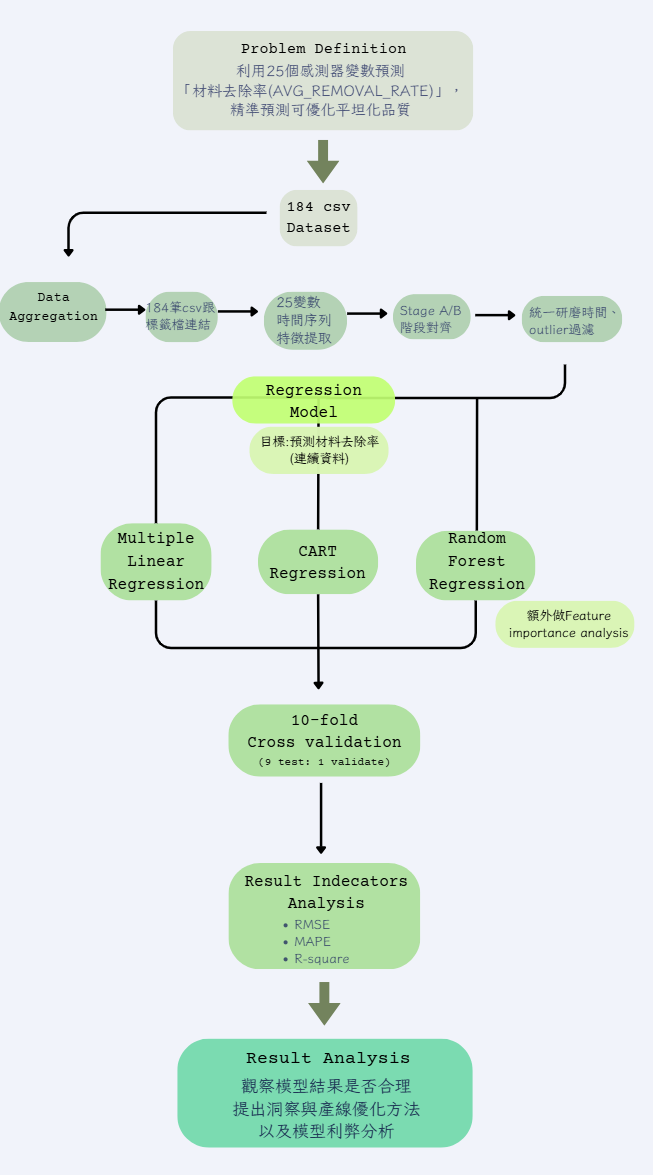

Based on the statistical analysis of the label file `training_removalrate.csv` and the associated sensor data files, the preliminary data summary is provided below:

### Sample Scale and Feature Dimensions
* Total Sample Size: 1,981 observations
* Feature Count:
    * Input Features (X): 25 process and equipment-related variables
      * e.g., Chamber Pressure, Slurry Flow Rate, Table Speed, and Consumable Usage.
    * Target Variable (Y): `AVG_REMOVAL_RATE`, a continuous numerical value representing the material removal performance.
* Data Structure: The raw sensor data consists of **high-frequency time-series signals (1 Hz)**. These signals are transformed into fixed-dimensional feature vectors through feature engineering (e.g., aggregating via Mean and Standard Deviation).

### Distribution Across Process Stages (STAGE A & B)
The analysis reveals significant physical and performance differences between the two stages:
* **Stage A (Primary Polishing)**:
    * Sample Count: **1,166** entries.
    * Mean Removal Rate: **111.67** (significantly higher than Stage B), indicating aggressive material removal.
    * Variability: A high standard deviation of **243.38** with extreme outliers (Max: 4326.15), suggesting a more volatile process environment.
* **Stage B (Final Buffing/Stabilization)**:
    * Sample Count: 815 entries.
    * Mean Removal Rate: 79.97, with a highly concentrated distribution.
    * Stability: A low standard deviation of **9.15**, with values strictly ranging between 54 and 101, indicating high process stability.

### Statistical Characteristics of Target Variable (AVG_REMOVAL_RATE)
* **Central Tendency**: The global mean is **98.63**, while the median is **79.15**. The fact that the mean is significantly higher than the median confirms a **highly right-skewed** distribution.
* **Dispersion**: The overall standard deviation is **187.43**, reflecting high cross-batch and cross-stage variance.
* **Outlier Observation**:
    * **Minimum**: 53.43.
    * **Maximum**: **4326.15**.
    * **Insights**: The extreme gap between the 75th percentile (88.7) and the maximum value confirms the presence of **extreme outliers**. 

## Data Quality Inspection and Preprocessing

We aggregate all the training files by following steps:
1. Using `glob` catch all the 185 files, and mark the empty files
2. Calculating the **Mean** (representing the process level) and **Standard Deviation** (capturing process stability and equipment vibration) for all 25 sensor variables.
3. Applying `unstack` method to flatten the statistics into a single-row feature vector
4. Label-integrating with "CMP-training-removalrate.csv" file, with "WAFER_ID" and "STAGE" as the primary keys.

In [ ]:
import pandas as pd
import glob
import os

base_path = r"C:\Users\user\OneDrive - 國立陽明交通大學\桌面\001__1142碩士生存指南\536907_製造數據科學_洪佑鑫\1142MDS_Project_313652018_Xuan-Wei-Wang\Assignment02\2016 PHM Data Challenge\2016 PHM DATA CHALLENGE CMP DATA SET\CMP-data"
training_data_path = os.path.join(base_path, "training")
label_file = os.path.join(base_path, "CMP-training-removalrate.csv")

file_list = glob.glob(os.path.join(training_data_path, "*.csv"))
print(f"Find {len(file_list)} sensor files, about to aggregate...")
summary_list = []
for i, file in enumerate(file_list):
    temp_df = pd.read_csv(file)
    
    if temp_df.empty:
        continue
        
    try:
        wafer_id = str(temp_df['WAFER_ID'].iloc[0])
        stage = str(temp_df['STAGE'].iloc[0])
        chamber_val = int(temp_df['CHAMBER'].iloc[0])
        stage_chamber_key = f"{stage}_{chamber_val}"
        
        cols_to_drop = ['WAFER_ID', 'STAGE', 'CHAMBER', 'TIMESTAMP', 'MACHINE_ID', 'MACHINE_DATA']
        numeric_features = temp_df.select_dtypes(include=['number']).drop(columns=[c for col in temp_df.columns for c in cols_to_drop if col == c], errors='ignore')
        
        stats = numeric_features.agg(['mean', 'std'])
        
        row_stats = stats.unstack().to_frame().T
        row_stats.columns = [f'{col[0]}_{col[1]}' for col in row_stats.columns]
        
        row_stats['Process_Duration'] = len(temp_df)
        row_stats['WAFER_ID'] = wafer_id
        row_stats['STAGE'] = stage
        row_stats['CHAMBER'] = chamber_val
        row_stats['STAGE_CHAMBER'] = stage_chamber_key 
        summary_list.append(row_stats)
        
    except Exception as e:
        print(f">>>>>> ERROR: File {os.path.basename(file)} is invalid: {str(e)}")
        continue

    if (i+1) % 50 == 0:
        print(f"====== PROGRESS: Processed {i+1} files...") 

df_features = pd.concat(summary_list, ignore_index=True)
labels = pd.read_csv(label_file)
labels['WAFER_ID'] = labels['WAFER_ID'].astype(str)
labels['STAGE'] = labels['STAGE'].astype(str)

df_final = pd.merge(df_features, labels, on=['WAFER_ID', 'STAGE'], how='inner')

print("\n===>>>>> SUCCESS: Data aggregation complete!<<<<<<===")
print(f"Final feature matrix shape: {df_final.shape}")

if 'STAGE_CHAMBER' in df_final.columns:
    print("\n[2.3 EDA Diagnosis Tip] Mean Removal Rate by Stage_Chamber:")
    print(df_final.groupby('STAGE_CHAMBER')['AVG_REMOVAL_RATE'].mean().sort_values(ascending=False))

df_final.head()

Find 185 sensor files, about to aggregate...
====== PROGRESS: Processed 50 files...
====== PROGRESS: Processed 100 files...
====== PROGRESS: Processed 150 files...

===>>>>> SUCCESS: Data aggregation complete!<<<<<<===
Final feature matrix shape: (184, 44)

[2.3 EDA Diagnosis Tip] Mean Removal Rate by Stage_Chamber:
STAGE_CHAMBER
A_1    188.713229
B_4     81.091557
A_4     73.252905
Name: AVG_REMOVAL_RATE, dtype: float64


,USAGE_OF_BACKING_FILM_mean,USAGE_OF_BACKING_FILM_std,USAGE_OF_DRESSER_mean,USAGE_OF_DRESSER_std,USAGE_OF_POLISHING_TABLE_mean,USAGE_OF_POLISHING_TABLE_std,USAGE_OF_DRESSER_TABLE_mean,USAGE_OF_DRESSER_TABLE_std,PRESSURIZED_CHAMBER_PRESSURE_mean,PRESSURIZED_CHAMBER_PRESSURE_std,...,DRESSING_WATER_STATUS_mean,DRESSING_WATER_STATUS_std,EDGE_AIR_BAG_PRESSURE_mean,EDGE_AIR_BAG_PRESSURE_std,Process_Duration,WAFER_ID,STAGE,CHAMBER,STAGE_CHAMBER,AVG_REMOVAL_RATE
0,9338.075348,80.511031,536.057573,4.722434,251.504029,89.195353,2667.598963,3.184136,52.752363,40.698930,...,0.542452,0.498263,30.924644,25.202157,3663,371447024,A,1,A_1,149.13090
1,9703.238113,86.864677,555.676669,3.804677,236.174626,77.198713,2680.840584,2.578330,58.225718,34.741006,...,0.328698,0.469784,34.128126,22.388594,5321,-875170052,B,4,B_4,65.91045
2,9991.971483,96.929373,572.558344,4.283878,127.033832,84.162334,2692.247485,2.883222,57.107475,40.485907,...,0.454467,0.497949,32.430797,24.865236,9246,371447032,A,1,A_1,149.99265
3,2972.610931,4537.516981,593.001318,4.288880,171.553078,91.691896,2706.046090,2.905676,54.466533,36.707887,...,0.501942,0.500023,31.256611,23.394538,9270,329446704,A,1,A_1,147.94095
4,418.110632,89.717660,609.219440,4.669346,125.133370,79.775997,2716.988978,3.133999,51.863476,36.692925,...,0.426232,0.494559,29.660509,22.800634,8120,329446870,A,1,A_1,147.02025


The previous table shows that:
1. Each row represents a single "WAFER_ID" and its"STAGE", and the information indecates the mean and std for each features during the stage process
2. The table is 184*(43+4) dimension:
   * Since 066.csv is empty, there are only 185-1=**184** files
   * There are 21 features for each wafer process, and each feature we compute its mean and std; therefore, there are 21*2+1= **43** features for each process, where 1 represents the time.
   * And lables are "WAFER_ID", "STAGE", "CHAMBER" and "AVG_REMOVAL_RATE"

During aggregation, it was discovered that the training CSV file 066 was completely blank.  
The following checks were performed:
1. Duplicate samples
2. Redundant columns
3. Missing values
4. Outliers

Number of duplicate rows: 0
Number of constant columns: 0
Constant columns: []
Number of missing values after merging: 0


C:\Users\user\AppData\Local\Temp\ipykernel_20036\261211350.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='STAGE', y='AVG_REMOVAL_RATE', data=df, ax=axes[0], palette='Set2')
C:\Users\user\AppData\Local\Temp\ipykernel_20036\261211350.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='STAGE', y='AVG_REMOVAL_RATE', data=df_filtered, ax=axes[1], palette='Set2')


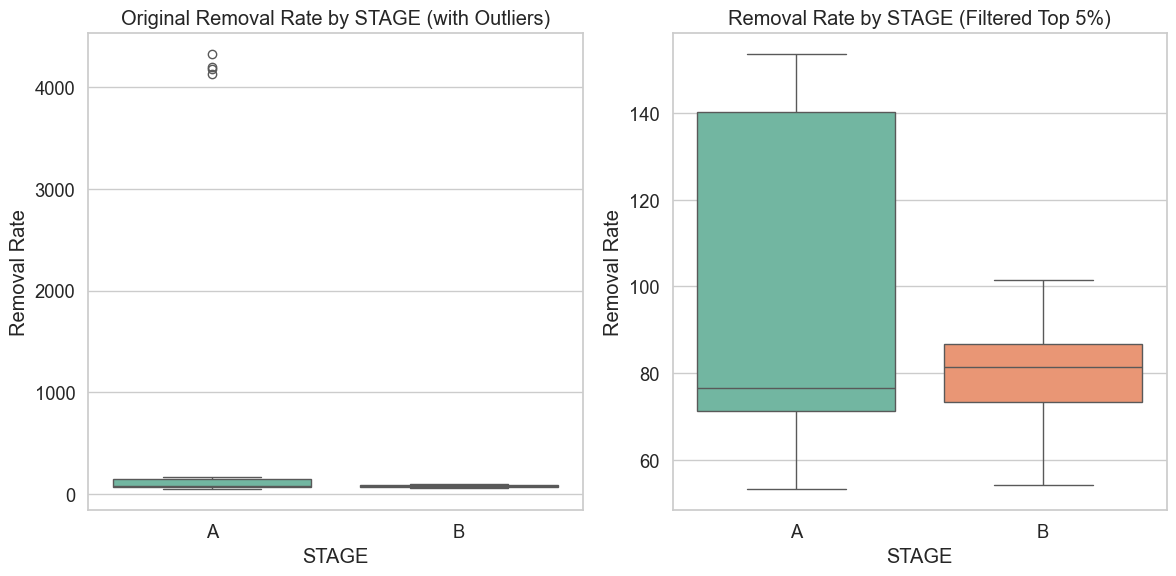

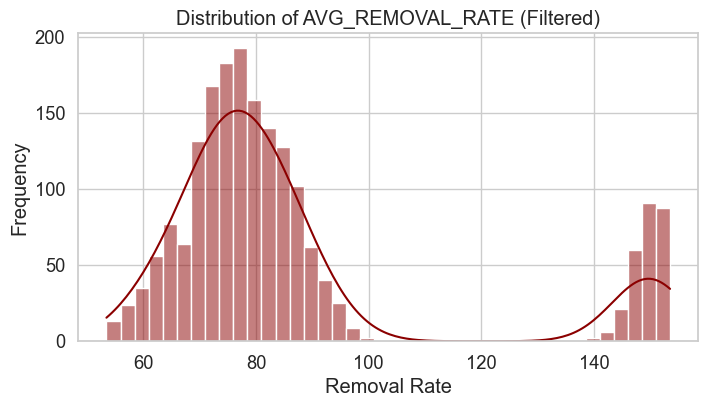

In [8]:
# Duplicate check
total_duplicates = df_final.duplicated().sum()
print(f"Number of duplicate rows: {total_duplicates}")
if total_duplicates > 0:
    print(df_final[df_final.duplicated()])
    
constant_cols = df_final.columns[df_final.nunique() <= 1].tolist()
print(f"Number of constant columns: {len(constant_cols)}")
print(f"Constant columns: {constant_cols}")

# Nan check
null_counts = df_final.isnull().sum().sum()
print(f"Number of missing values after merging: {null_counts}")

import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# A. Exploratory Boxplot with Outliers
sns.boxplot(x='STAGE', y='AVG_REMOVAL_RATE', data=df, ax=axes[0], palette='Set2')
axes[0].set_title('Original Removal Rate by STAGE (with Outliers)')
axes[0].set_ylabel('Removal Rate')

# B. Boxplot with Outliers Removed (Filter Top 5%)
q_limit = df['AVG_REMOVAL_RATE'].quantile(0.95)
df_filtered = df[df['AVG_REMOVAL_RATE'] < q_limit]

sns.boxplot(x='STAGE', y='AVG_REMOVAL_RATE', data=df_filtered, ax=axes[1], palette='Set2')
axes[1].set_title('Removal Rate by STAGE (Filtered Top 5%)')
axes[1].set_ylabel('Removal Rate')

plt.tight_layout()
plt.show()

# C. Histogram
plt.figure(figsize=(8, 4))
sns.histplot(df_filtered['AVG_REMOVAL_RATE'], kde=True, color='darkred', bins=40)
plt.title('Distribution of AVG_REMOVAL_RATE (Filtered)')
plt.xlabel('Removal Rate')
plt.ylabel('Frequency')
plt.show()


* Duplicate Check: None
* Feature Variance: None
* Missing Values: None
* From the two table above, extreme outlier at 4326.15 removed to restore normal process distribution visibility.

## EDA Analysis

### Relationship between Process Stage and Removal Rate
* Objective: To verify the significant difference in removal efficiency between Stage A (Rough Polishing) and Stage B (Fine Polishing).
* The results are primarily related to **Chambers 1 and 4 of Stage A**, and **Chamber 4 of Stage B**.
  * => **Subdividing the original Stage A vs B into A_1, A_4, and B_4** allows you to elevate your report from a simple "process stage comparison" to a "machine chamber performance diagnosis."
  
Such a chart enables you to observe two key dimensions simultaneously:
* **Chamber Differences**: Comparing A_1 and A_4 (same stage, different chambers).
* **Stage Transitions**: Comparing A_4 and B_4 (same chamber, different stages).

C:\Users\user\AppData\Local\Temp\ipykernel_20036\3859287372.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


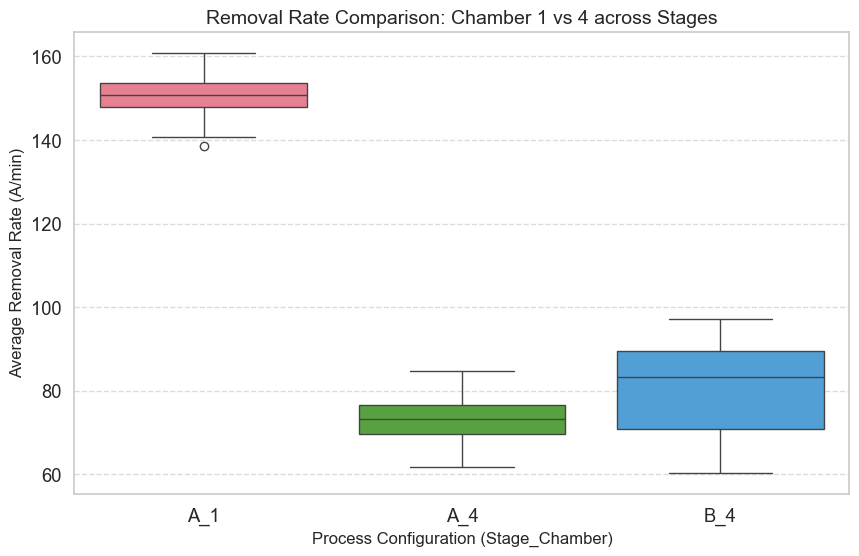

In [9]:
df_clean = df_final[df_final['AVG_REMOVAL_RATE'] < 500].copy()
plt.figure(figsize=(10, 6))

plot_order = ['A_1', 'A_4', 'B_4']

sns.boxplot(
    x='STAGE_CHAMBER', 
    y='AVG_REMOVAL_RATE', 
    data=df_clean, 
    order=plot_order, 
    palette='husl'
)

plt.title('Removal Rate Comparison: Chamber 1 vs 4 across Stages', fontsize=14)
plt.xlabel('Process Configuration (Stage_Chamber)', fontsize=12)
plt.ylabel('Average Removal Rate (A/min)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

#### 1. Systematic Bias Between Chambers
* **Observation**: Comparison between A_1 and A_4 (both in the rough polishing stage).
* **Diagnosis**: The Material Removal Rate (RR) of Chamber 1 is significantly higher than that of Chamber 4. Although both may share the same process recipe, Chamber 1 exhibits higher polishing efficiency.
* **Physical Significance**: This indicates hardware-level inconsistencies between machine chambers. When building Virtual Metrology (VM) models, failing to consider the CHAMBER factor will lead to severe prediction bias.

#### 2. Process Intensity Shift
* **Observation**: Comparison between A_4 and B_4 (same chamber, different stages).
* **Diagnosis**: Stage A_4 is rough polishing; theoretically, its AVG_REMOVAL_RATE should be higher than Stage B_4, yet the data shows the opposite.
* **Potential Defects**: 
  * This implies that the **Stage A-Chamber_4** (e.g., nozzle pressure, polishing head flatness) **may have systemic defects**, causing its performance to fall below expectations.

### Relationship between Features and Removal Rate across Three Processes
Objective: This is critical for diagnosing "process degradation."
* Conduct correlation analysis between each feature and the removal rate.
* Identify and analyze the characteristics of the top-ranked features based on their correlation.

In [12]:
groups = ['A_1', 'A_4', 'B_4']
top_n = 10
group_corrs = {}

for g in groups:
    df_sub = df_clean[df_clean['STAGE_CHAMBER'] == g]
    corr_matrix = df_sub.corr(numeric_only=True)
    target_corr = corr_matrix['AVG_REMOVAL_RATE'].drop(['AVG_REMOVAL_RATE', 'CHAMBER', 'Process_Duration'], errors='ignore')
    top_feature_names = target_corr.abs().sort_values(ascending=False).head(top_n).index
    group_corrs[g] = target_corr[top_feature_names]

for g, results in group_corrs.items():
    print(f"\n===== [Category] {g}] top {top_n} key features =====")
    print(results)



===== [Category] A_1] top 10 key features =====
USAGE_OF_DRESSER_TABLE_mean        0.353104
USAGE_OF_PRESSURIZED_SHEET_mean    0.290024
USAGE_OF_BACKING_FILM_mean         0.290024
USAGE_OF_MEMBRANE_mean             0.290024
USAGE_OF_DRESSER_mean             -0.256314
USAGE_OF_DRESSER_TABLE_std         0.242061
USAGE_OF_DRESSER_std               0.240546
USAGE_OF_POLISHING_TABLE_std       0.221237
RETAINER_RING_PRESSURE_std         0.214587
RETAINER_RING_PRESSURE_mean        0.207943
Name: AVG_REMOVAL_RATE, dtype: float64

===== [Category] A_4] top 10 key features =====
USAGE_OF_DRESSER_TABLE_mean        0.558757
RETAINER_RING_PRESSURE_std         0.527909
SLURRY_FLOW_LINE_A_std             0.334333
USAGE_OF_DRESSER_std              -0.234632
SLURRY_FLOW_LINE_A_mean            0.207645
HEAD_ROTATION_std                  0.195881
HEAD_ROTATION_mean                -0.189402
USAGE_OF_BACKING_FILM_mean        -0.184897
USAGE_OF_MEMBRANE_mean            -0.184897
USAGE_OF_PRESSURIZED_SHEET_

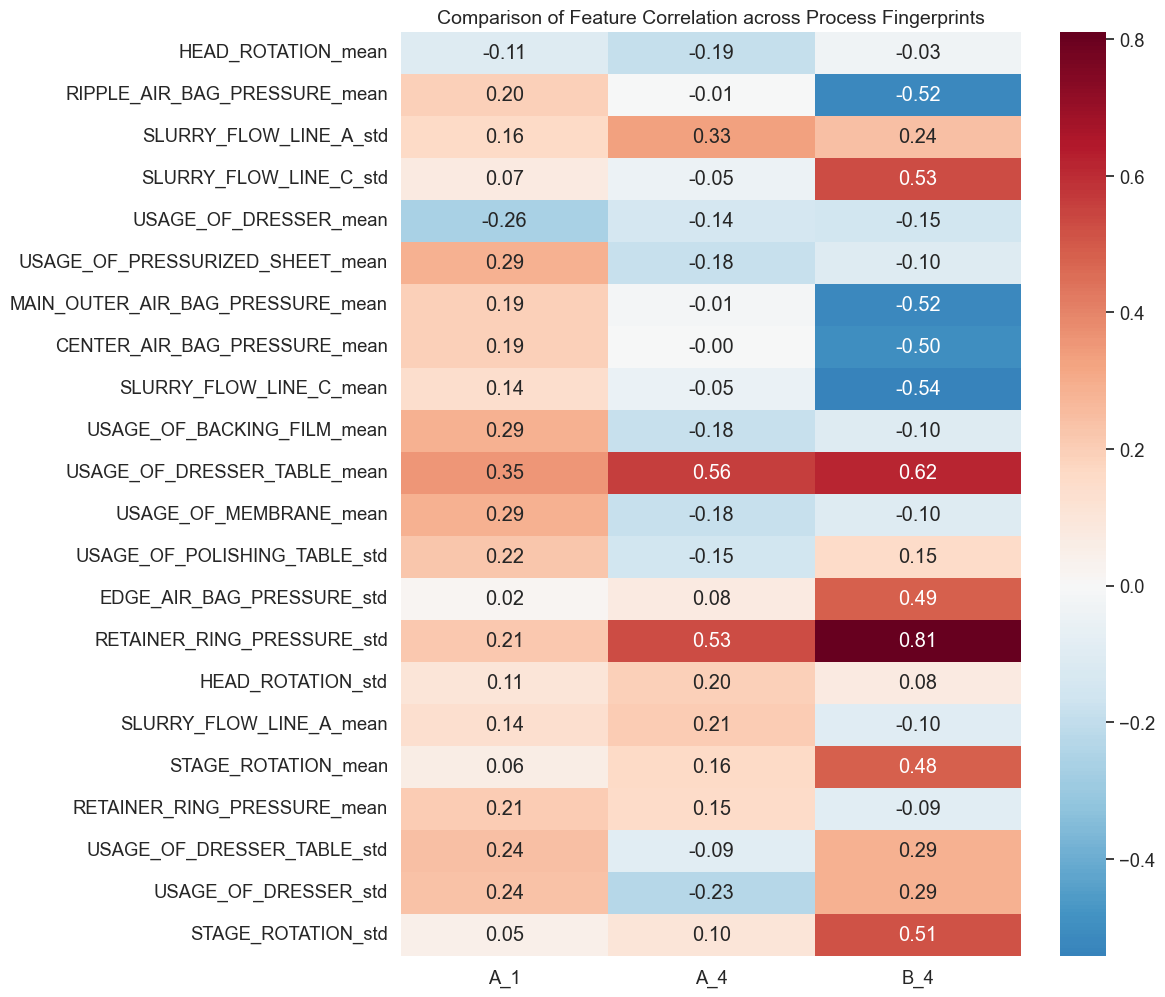

In [13]:
all_top_features = []
for results in group_corrs.values():
    all_top_features.extend(results.index.tolist())
unique_top_features = list(set(all_top_features))
summary_df = pd.DataFrame(index=unique_top_features)
for g in groups:
    df_sub = df_clean[df_clean['STAGE_CHAMBER'] == g]
    summary_df[g] = df_sub.corr(numeric_only=True).loc[unique_top_features, 'AVG_REMOVAL_RATE']

plt.figure(figsize=(10, 12))
sns.heatmap(summary_df, annot=True, cmap='RdBu_r', center=0, fmt='.2f')
plt.title('Comparison of Feature Correlation across Process Fingerprints', fontsize=14)
plt.show()

#### Observations and Conclusions
1. **Chamber Heterogeneity**:
   * **Observation**: Comparing A_1 and A_4, it was found that the feature sets dominating the removal rate do not overlap.
   * **Physical Significance**: Even under the same Stage A, Chamber 1 and Chamber 4 exhibit "equipment personality differences" in their response to sensor signals. This indicates that the model must incorporate the chamber factor (STAGE_CHAMBER) to correct systematic bias.

2. **Key Stability Factor in Fine Polishing (B_4 Dominance)**:
   * **Observation**: In the B_4 group, `RETAINER_RING_PRESSURE_std` showed an extremely high positive correlation ($r \approx 0.81$).
   * **Physical Significance**: This suggests that during the fine polishing stage, pressure fluctuations (volatility) have far greater explanatory power for the final removal rate than average pressure, making it a core monitoring metric for maintaining polishing quality.

### Correlation Between Features across Three Processes

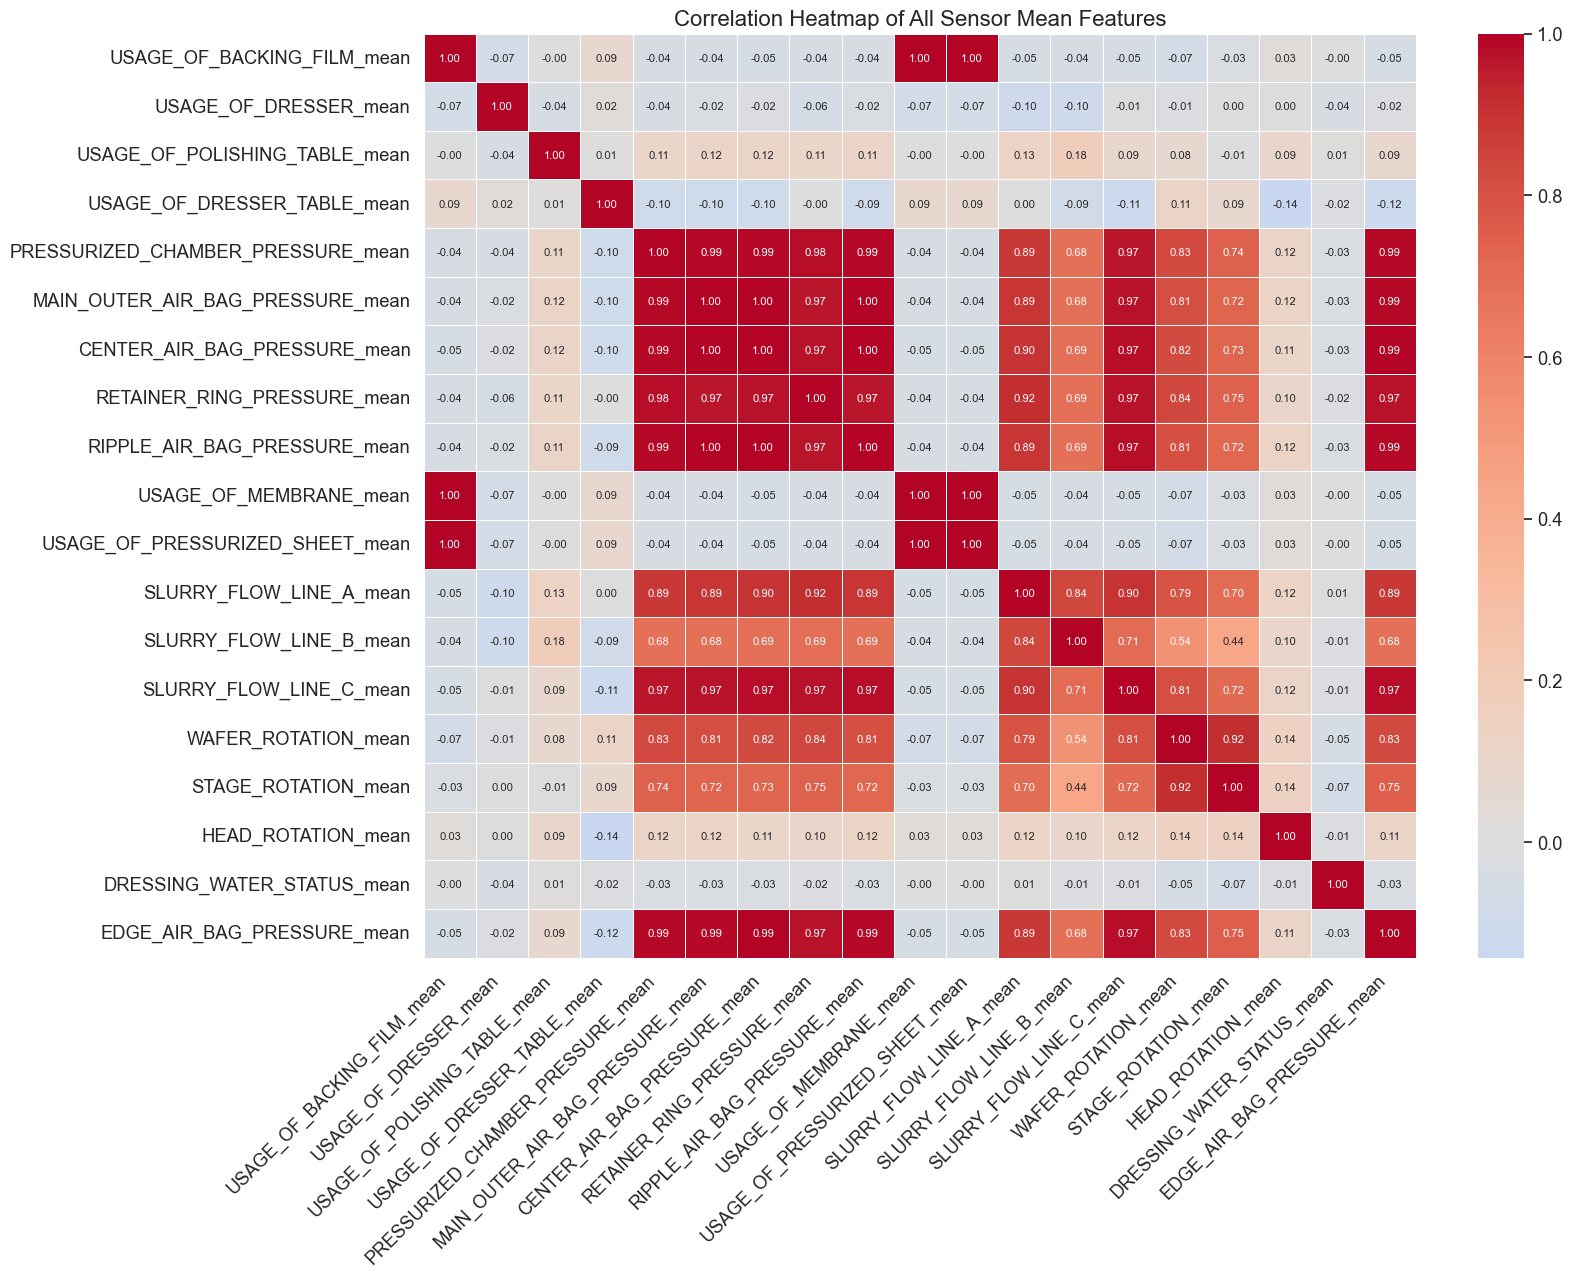

In [14]:
mean_features = [col for col in df_clean.columns if '_mean' in col]
mean_corr_matrix = df_clean[mean_features].corr()
plt.figure(figsize=(16, 12)) 
sns.heatmap(
    mean_corr_matrix, 
    annot=True, 
    cmap='coolwarm', 
    center=0, 
    fmt='.2f', 
    annot_kws={"size": 8}, 
    linewidths=0.5
)

plt.title('Correlation Heatmap of All Sensor Mean Features', fontsize=16)
plt.xticks(rotation=45, ha='right') 
plt.show()

In [16]:
import numpy as np
feature_cols = [col for col in df_clean.columns if '_mean' in col or '_std' in col]
corr_matrix = df_clean[feature_cols].corr().abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
top_pairs = upper_tri.unstack().dropna().sort_values(ascending=False)

print("--- Top 10 Feature Pairs by Correlation (Absolute Value) ---")
for i, ((f1, f2), val) in enumerate(top_pairs.head(10).items()):
    print(f"{i+1:2d}. {val:.6f} | {f1}  <-->  {f2}")

--- Top 10 Feature Pairs by Correlation (Absolute Value) ---
 1. 1.000000 | USAGE_OF_PRESSURIZED_SHEET_mean  <-->  USAGE_OF_MEMBRANE_mean
 2. 1.000000 | USAGE_OF_MEMBRANE_mean  <-->  USAGE_OF_BACKING_FILM_mean
 3. 1.000000 | USAGE_OF_PRESSURIZED_SHEET_mean  <-->  USAGE_OF_BACKING_FILM_mean
 4. 1.000000 | USAGE_OF_PRESSURIZED_SHEET_std  <-->  USAGE_OF_MEMBRANE_std
 5. 1.000000 | USAGE_OF_MEMBRANE_std  <-->  USAGE_OF_BACKING_FILM_std
 6. 1.000000 | USAGE_OF_PRESSURIZED_SHEET_std  <-->  USAGE_OF_BACKING_FILM_std
 7. 0.997695 | RIPPLE_AIR_BAG_PRESSURE_mean  <-->  MAIN_OUTER_AIR_BAG_PRESSURE_mean
 8. 0.995704 | CENTER_AIR_BAG_PRESSURE_mean  <-->  MAIN_OUTER_AIR_BAG_PRESSURE_mean
 9. 0.995109 | RIPPLE_AIR_BAG_PRESSURE_mean  <-->  CENTER_AIR_BAG_PRESSURE_mean
10. 0.993282 | EDGE_AIR_BAG_PRESSURE_mean  <-->  CENTER_AIR_BAG_PRESSURE_mean


From the above result, we will cut of some of the features in the process of question 2.4.

## Model Construct and Analysis - Predict AVG_REMOVAL_RATE

#### Feature Selection
Based on the findings from the EDA phase, this study adopts the "Filter Method" and "Physical Significance Preservation" approach for feature selection:

* **Eliminating Highly Collinear Features**:
    * **Consumables Group**: Discovered that `PRESSURIZED_SHEET` and `MEMBRANE` data are perfectly synchronized with `BACKING_FILM` ($r=1.0$). Therefore, only the mean and standard deviation of `USAGE_OF_BACKING_FILM` are retained.
    * **Pressure System**: Air bag pressure feature groups show correlations higher than $0.99$. To streamline model dimensionality, only the `CENTER` and `EDGE` air bag pressure features, which are most representative of the process, are retained.

* **Retaining Key Sensing Features**:
    * Retain **Standard Deviation (std)** features for all sensors, especially `RETAINER_RING_PRESSURE_std`, as it demonstrated strong explanatory power during the fine polishing stage.
    * Retain `Process_Duration` as an indicator of total process time.

In [17]:
# Cleaning redundant features based on correlation analysis
drop_cols = [
    'USAGE_OF_PRESSURIZED_SHEET_mean', 'USAGE_OF_PRESSURIZED_SHEET_std',
    'USAGE_OF_MEMBRANE_mean', 'USAGE_OF_MEMBRANE_std',
    'RIPPLE_AIR_BAG_PRESSURE_mean', 'RIPPLE_AIR_BAG_PRESSURE_std',
    'MAIN_OUTER_AIR_BAG_PRESSURE_mean', 'MAIN_OUTER_AIR_BAG_PRESSURE_std'
]

df_final_selected = df_clean.drop(columns=drop_cols, errors='ignore')

print(f"Original number of Features: {df_clean.shape[1]}")
print(f"Selected number ofFeatures: {df_final_selected.shape[1]}")

Original number of Features: 44
Selected number ofFeatures: 36


#### Feature Engineering (Completed)
To address the non-linearity and machine variations within the process, the following transformations were performed:

* **Stage-Chamber Fingerprint Encoding**:
    * Merged `STAGE` (A/B) and `CHAMBER` (1-6) into a composite variable `STAGE_CHAMBER`.
    * **Rationale**: EDA revealed significant performance offsets between machines within the same stage (A_1 vs. A_4), as well as different physical responses for the same machine across different stages (A_4 vs. B_4).
    * **Implementation**: Applied **One-Hot Encoding** to convert the composite labels into dummy variables, allowing the model to learn intercept corrections specific to each "Machine + Stage" combination.

* **Feature Scaling**:
    * Utilized **StandardScaler** to standardize numerical features.
    * **Rationale**: Different sensors (e.g., pressure vs. rotational speed) operate on different scales; standardization ensures stable and interpretable weights for the linear model.

#### Model Selection Rationale

1. **Multiple Linear Regression**
    * **Reasons**: Robust baseline for small samples (n=184); provides high physical interpretability through regression coefficients to verify process logic.

2. **CART Regression Model**
    * **Reasons**: Effectively captures non-linear process thresholds and stage-based decision rules without requiring complex feature scaling or transformation.

3. **Random Forest**
    * **Reasons**: An ensemble method reducing individual tree variance; offers superior robustness against sensor noise and ranks feature importance effectively.

#### Training & Validation
To ensure the model's generalization ability and evaluate its prediction performance in a real-world production line, the following process was adopted:

* **Data Splitting**: The data was randomly partitioned into an **80% Training Set** and a **20% Test Set**.
* **5-Fold Cross Validation**: Cross-validation was performed within the training set to ensure that model parameters do not overly depend on a specific sample split.
* **Evaluation Metrics**:
    * **$R^2$ Score**: Measures the model's ability to explain the variance in the material removal rate.
    * **Mean Absolute Error (MAE)**: Measures the average absolute deviation between the predicted removal rate and the actual measured value (Unit: $\text{Å/min}$).

### Coding Space ---

In [18]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error

# ==========================================
#  Path configurations (Adjust paths as needed)
# ==========================================
train_label_path = r"C:\Users\user\OneDrive - 國立陽明交通大學\桌面\001__1142碩士生存指南\536907_製造數據科學_洪佑鑫\1142MDS_Project_313652018_Xuan-Wei-Wang\Assignment02\2016 PHM Data Challenge\2016 PHM DATA CHALLENGE CMP DATA SET\CMP-data\training_removalrate.csv"
test_folder_path = r"C:\Users\user\OneDrive - 國立陽明交通大學\桌面\001__1142碩士生存指南\536907_製造數據科學_洪佑鑫\1142MDS_Project_313652018_Xuan-Wei-Wang\Assignment02\2016 PHM Data Challenge\2016 PHM DATA CHALLENGE CMP DATA SET\CMP-data\test"
test_label_path  = r"C:\Users\user\OneDrive - 國立陽明交通大學\桌面\001__1142碩士生存指南\536907_製造數據科學_洪佑鑫\1142MDS_Project_313652018_Xuan-Wei-Wang\Assignment02\2016 PHM Data Challenge\2016 PHM DATA CHALLENGE CMP DATA SET\CMP-data\CMP-test-removalrate.csv"

def aggregate_cmp_data(folder_path):
    aggregated_data = []
    file_list = [f for f in os.listdir(folder_path) if f.endswith('.csv')]
    
    for file in file_list:
        file_full_path = os.path.join(folder_path, file)
        df_temp = pd.read_csv(file_full_path)
        if df_temp.empty:
            print(f"Skipping empty file: {file}")
            continue
            
        required_cols = ['WAFER_ID', 'STAGE', 'CHAMBER']
        if not all(col in df_temp.columns for col in required_cols):
            print(f"Skipping file with missing columns: {file}")
            continue
        # -----------------------
        wafer_id = df_temp['WAFER_ID'].iloc[0]
        stage = df_temp['STAGE'].iloc[0]
        chamber = df_temp['CHAMBER'].iloc[0]

        numeric_df = df_temp.select_dtypes(include=[np.number]).drop(columns=['WAFER_ID', 'CHAMBER'], errors='ignore')
        stats_mean = numeric_df.mean().add_suffix('_mean')
        stats_std = numeric_df.std().add_suffix('_std')
        
        combined = pd.concat([stats_mean, stats_std])
        combined['WAFER_ID'] = wafer_id
        combined['STAGE'] = stage
        combined['CHAMBER'] = chamber
        aggregated_data.append(combined)
        
    if not aggregated_data:
        print("Warning: No valid data found in the test folder. Returning empty DataFrame.")
        return pd.DataFrame()
        
    return pd.DataFrame(aggregated_data)

df_train_raw = df_clean.copy() 

print("Aggregating test data from files...")
df_test_raw = aggregate_cmp_data(test_folder_path)
test_labels = pd.read_csv(test_label_path)
df_test_final = pd.merge(df_test_raw, test_labels, on=['WAFER_ID', 'STAGE'])

df_train_raw['STAGE_CHAMBER'] = df_train_raw['STAGE'] + "_" + df_train_raw['CHAMBER'].astype(str)
df_test_final['STAGE_CHAMBER'] = df_test_final['STAGE'] + "_" + df_test_final['CHAMBER'].astype(str)

drop_cols = [
    'USAGE_OF_PRESSURIZED_SHEET_mean', 'USAGE_OF_PRESSURIZED_SHEET_std',
    'USAGE_OF_MEMBRANE_mean', 'USAGE_OF_MEMBRANE_std',
    'RIPPLE_AIR_BAG_PRESSURE_mean', 'RIPPLE_AIR_BAG_PRESSURE_std',
    'MAIN_OUTER_AIR_BAG_PRESSURE_mean', 'MAIN_OUTER_AIR_BAG_PRESSURE_std'
]

# Preparing training X, y
X_train_full = df_train_raw.drop(columns=['WAFER_ID', 'AVG_REMOVAL_RATE', 'STAGE', 'CHAMBER']).drop(columns=drop_cols, errors='ignore')
y_train_full = df_train_raw['AVG_REMOVAL_RATE']

# Preparing external test X, y
X_test_ext = df_test_final.drop(columns=['WAFER_ID', 'AVG_REMOVAL_RATE', 'STAGE', 'CHAMBER']).drop(columns=drop_cols, errors='ignore')
y_test_ext = df_test_final['AVG_REMOVAL_RATE']

# One-Hot Encoding
X_train_full = pd.get_dummies(X_train_full, columns=['STAGE_CHAMBER'])
X_test_ext = pd.get_dummies(X_test_ext, columns=['STAGE_CHAMBER'])

X_test_ext = X_test_ext.reindex(columns=X_train_full.columns, fill_value=0)


Aggregating test data from files...
Skipping empty file: CMP-test-008.csv
Skipping empty file: CMP-test-014.csv
Skipping empty file: CMP-test-019.csv
Skipping empty file: CMP-test-020.csv
Skipping empty file: CMP-test-030.csv
Skipping empty file: CMP-test-031.csv
Skipping empty file: CMP-test-040.csv
Skipping empty file: CMP-test-041.csv
Skipping empty file: CMP-test-042.csv
Skipping empty file: CMP-test-046.csv
Skipping empty file: CMP-test-051.csv
Skipping empty file: CMP-test-056.csv
Skipping empty file: CMP-test-060.csv
Skipping empty file: CMP-test-066.csv
Skipping empty file: CMP-test-070.csv
Skipping empty file: CMP-test-077.csv
Skipping empty file: CMP-test-082.csv
Skipping empty file: CMP-test-083.csv
Skipping empty file: CMP-test-084.csv
Skipping empty file: CMP-test-101.csv
Skipping empty file: CMP-test-102.csv
Skipping empty file: CMP-test-110.csv
Skipping empty file: CMP-test-129.csv
Skipping empty file: CMP-test-132.csv
Skipping empty file: CMP-test-137.csv
Skipping empty

In [ ]:
# Standardization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_full)
X_test_ext_scaled = scaler.transform(X_test_ext)

# ==========================================
# Linear Regression Model 
# ==========================================

model = LinearRegression()
model.fit(X_train_scaled, y_train_full)
y_pred_ext = model.predict(X_test_ext_scaled)

print("\n" + "="*30)
print("Model Evaluation on External Test Set:")
print("="*30)
print(f"R2 Score: {r2_score(y_test_ext, y_pred_ext):.4f}")
print(f"MAE: {mean_absolute_error(y_test_ext, y_pred_ext):.4f} A/min")


Model Evaluation on External Test Set:
R2 Score: -0.1217
MAE: 36.9881 A/min


Test set size: 155
Average Y in Training Set: 119.66
Average Y in Test Set: 101.25


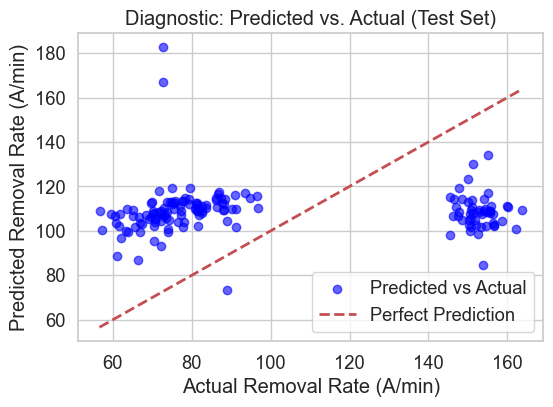

In [22]:
print(f"Test set size: {len(y_test_ext)}")

print(f"Average Y in Training Set: {y_train_full.mean():.2f}")
print(f"Average Y in Test Set: {y_test_ext.mean():.2f}")

plt.figure(figsize=(6, 4))
plt.scatter(y_test_ext, y_pred_ext, color='blue', alpha=0.6, label='Predicted vs Actual')
plt.plot([y_test_ext.min(), y_test_ext.max()], [y_test_ext.min(), y_test_ext.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Removal Rate (A/min)')
plt.ylabel('Predicted Removal Rate (A/min)')
plt.title('Diagnostic: Predicted vs. Actual (Test Set)')
plt.legend()
plt.grid(True)
plt.show()

##### Linear Regression - Model Evaluation & Diagnostics :
* **Data Representativeness Issues**: In the external test set, 30 sensor log files were found to be empty, leading to a reduction in the test sample size and increasing the variability of evaluation metrics.
    * **Regression Plot of the Test Set**: The blue data points almost form a horizontal line, indicating that the model "hesitates to predict extreme values." Consequently, the model tends to output a safe "mean value."
* **Prediction Failure Analysis**: Analysis reveals that the model's learning of the complex interaction between `STAGE_CHAMBER` was unstable due to the limited sample size.
* **Improvement Strategies**: Future work could consider implementing **Ridge Regression** with $L_2$ regularization to constrain model coefficients, or adopting more robust non-linear models like **Random Forest** to better account for machine offsets in the CMP process.

In [23]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

# ==========================================
# CART Regression Model
# ==========================================
cart_model = DecisionTreeRegressor(max_depth=5, random_state=42)
cart_model.fit(X_train_full, y_train_full) 

y_pred_cart = cart_model.predict(X_test_ext)

print(f"--- CART Performance ---")
print(f"R2 Score: {r2_score(y_test_ext, y_pred_cart):.4f}")
print(f"MAE: {mean_absolute_error(y_test_ext, y_pred_cart):.4f}")

# ==========================================
# Random Forest
# ==========================================
rf_model = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
rf_model.fit(X_train_full, y_train_full)

y_pred_rf = rf_model.predict(X_test_ext)

print(f"\n--- Random Forest Performance ---")
print(f"R2 Score: {r2_score(y_test_ext, y_pred_rf):.4f}")
print(f"MAE: {mean_absolute_error(y_test_ext, y_pred_rf):.4f}")

--- CART Performance ---
R2 Score: -0.3742
MAE: 29.3977

--- Random Forest Performance ---
R2 Score: -0.4886
MAE: 29.2228
